In [2]:
import sqlite3
import json

db_name = "my_library.db"

fake_api_response = """
[
    {"title": "The Alchemist", "author": "Paulo Coelho", "year": 1988},
    {"title": "To Kill a Mockingbird", "author": "Harper Lee", "year": 1960},
    {"title": "1984", "author": "George Orwell", "year": 1949},
    {"title": "The Great Gatsby", "author": "F. Scott Fitzgerald", "year": 1925},
    {"title": "Harry Potter", "author": "J.K. Rowling", "year": 1997}
]
"""

books_data = json.loads(fake_api_response)

db_conn = sqlite3.connect(db_name)
db_cursor = db_conn.cursor()

db_cursor.execute("DROP TABLE IF EXISTS books")
db_cursor.execute("""
    CREATE TABLE books (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        title TEXT,
        author TEXT,
        publication_year INTEGER
    )
""")

for item in books_data:
    db_cursor.execute(
        "INSERT INTO books (title, author, publication_year) VALUES (?, ?, ?)",
        (item["title"], item["author"], item["year"])
    )
db_conn.commit()

db_cursor.execute("SELECT id, title, author, publication_year FROM books")
saved_rows = db_cursor.fetchall()

print("ID\tTitle\t\t\tAuthor\t\t\tYear")
print("-" * 70)
for row in saved_rows:
    print(f"{row[0]}\t{row[1]:<24}\t{row[2]:<20}\t{row[3]}")

db_conn.close()

ID	Title			Author			Year
----------------------------------------------------------------------
1	The Alchemist           	Paulo Coelho        	1988
2	To Kill a Mockingbird   	Harper Lee          	1960
3	1984                    	George Orwell       	1949
4	The Great Gatsby        	F. Scott Fitzgerald 	1925
5	Harry Potter            	J.K. Rowling        	1997


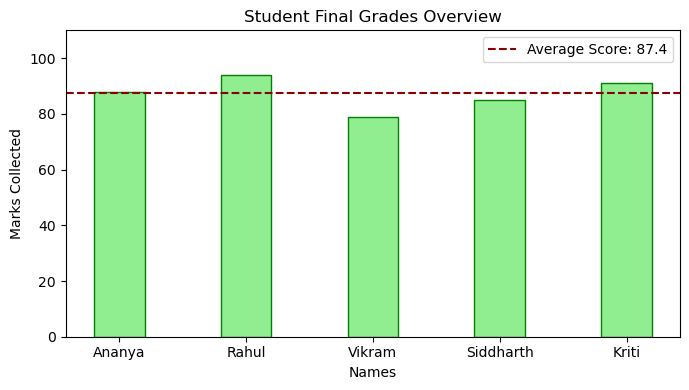

In [3]:
import matplotlib.pyplot as plt

student_records = [
    {"name": "Ananya", "score": 88},
    {"name": "Rahul", "score": 94},
    {"name": "Vikram", "score": 79},
    {"name": "Siddharth", "score": 85},
    {"name": "Kriti", "score": 91}
]

names_list = []
scores_list = []

for item in student_records:
    names_list.append(item["name"])
    scores_list.append(item["score"])

sum_of_scores = 0
for val in scores_list:
    sum_of_scores += val
average_mark = sum_of_scores / len(scores_list)

plt.figure(figsize=(7, 4))
plt.bar(names_list, scores_list, color="lightgreen", edgecolor="green", width=0.4)
plt.axhline(average_mark, color="darkred", linestyle="--", label=f"Average Score: {average_mark}")

plt.title("Student Final Grades Overview")
plt.xlabel("Names")
plt.ylabel("Marks Collected")
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
import csv
import sqlite3

csv_file_path = "directory.csv"
database_file = "records.db"

with open(csv_file_path, mode="w", newline="") as out_file:
    obj = csv.writer(out_file)
    obj.writerow(["name", "email"])
    obj.writerow(["Aarav Mehta", "aarav@testmail.com"])
    obj.writerow(["Sneha Rao", "sneha@testmail.com"])
    obj.writerow(["Kabir Singh", "kabir@testmail.com"])

conn_instance = sqlite3.connect(database_file)
cursor_obj = conn_instance.cursor()

cursor_obj.execute("DROP TABLE IF EXISTS users")
cursor_obj.execute("""
    CREATE TABLE users (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT,
        email TEXT UNIQUE
    )
""")
conn_instance.commit()

with open(csv_file_path, mode="r") as target:
    parsed_lines = csv.DictReader(target)
    for line in parsed_lines:
        name_str = line["name"].strip()
        email_str = line["email"].strip()
        
        if name_str and "@" in email_str:
            try:
                cursor_obj.execute(
                    "INSERT INTO users (name, email) VALUES (?, ?)", 
                    (name_str, email_str)
                )
            except sqlite3.IntegrityError:
                pass

conn_instance.commit()

cursor_obj.execute("SELECT id, name, email FROM users")
results_dump = cursor_obj.fetchall()

print("ID\tName\t\t\tEmail")
print("-" * 55)
for user_row in results_dump:
    print(f"{user_row[0]}\t{user_row[1]:<20}\t{user_row[2]}")

conn_instance.close()


ID	Name			Email
-------------------------------------------------------
1	Aarav Mehta         	aarav@testmail.com
2	Sneha Rao           	sneha@testmail.com
3	Kabir Singh         	kabir@testmail.com
